In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
team_colors = {
    'Mumbai Indians': '#004BA0',
    'Chennai Super Kings': '#F7DC6F',
    'Royal Challengers Bangalore': '#C70039',
    'Kolkata Knight Riders': '#4B0082',
    'Delhi Capitals': '#1E90FF',
    'Punjab Kings': '#D71920',
    'Rajasthan Royals': '#FF69B4',
    'Sunrisers Hyderabad': '#FF8C00',
    'Lucknow Super Giants': '#00CED1',
    'Gujarat Titans': '#000080'
}

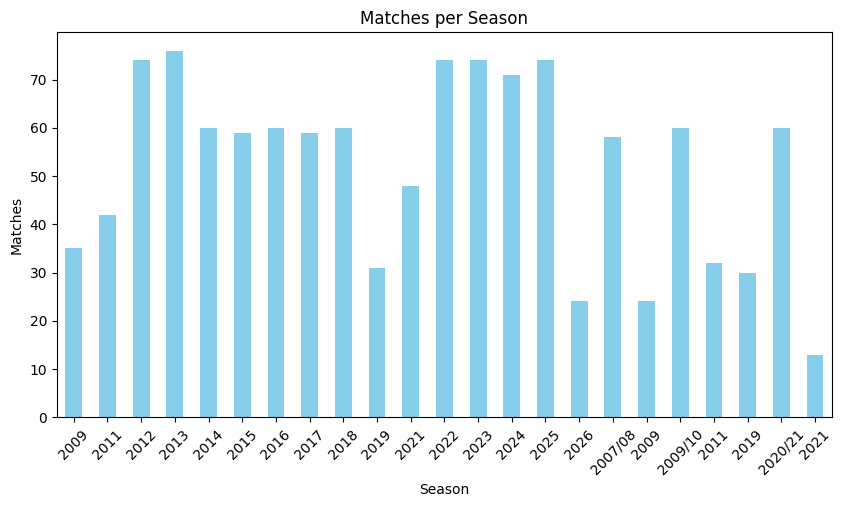

In [49]:
matches_per_season = df.groupby('season')['match_id'].nunique()

plt.figure(figsize=(10,5))
matches_per_season.plot(kind='bar', color='skyblue')

plt.title("Matches per Season")
plt.xlabel("Season")
plt.ylabel("Matches")
plt.xticks(rotation=45)

plt.show()

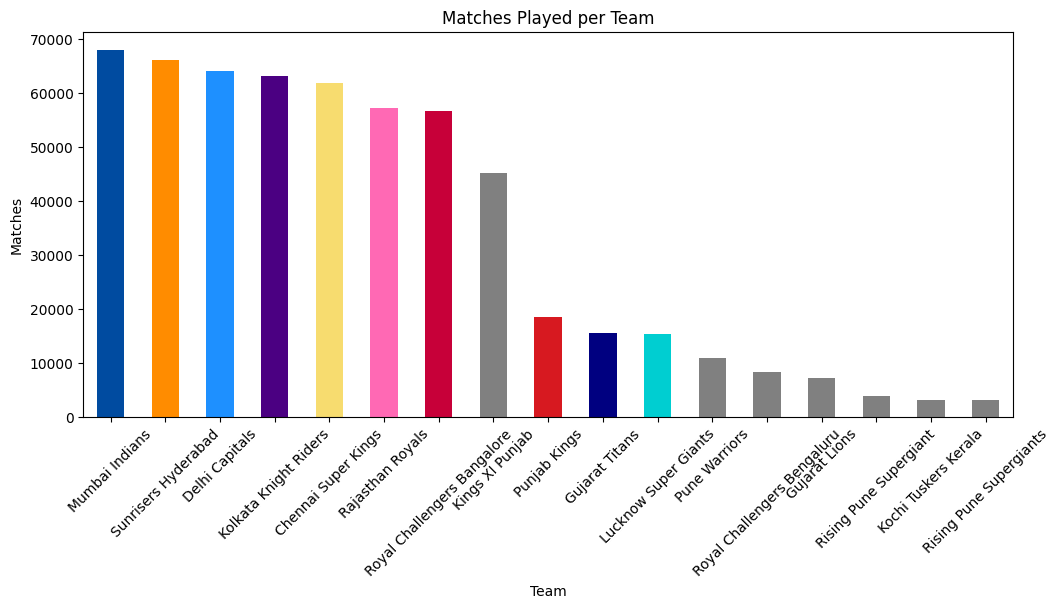

In [53]:
teams = pd.concat([df['batting_team'], df['bowling_team']])
matches_per_team = teams.value_counts()

colors = [team_colors.get(team, 'gray') for team in matches_per_team.index]

plt.figure(figsize=(12,5))
matches_per_team.plot(kind='bar', color=colors)

plt.title("Matches Played per Team")
plt.xlabel("Team")
plt.ylabel("Matches")
plt.xticks(rotation=45)

plt.show()

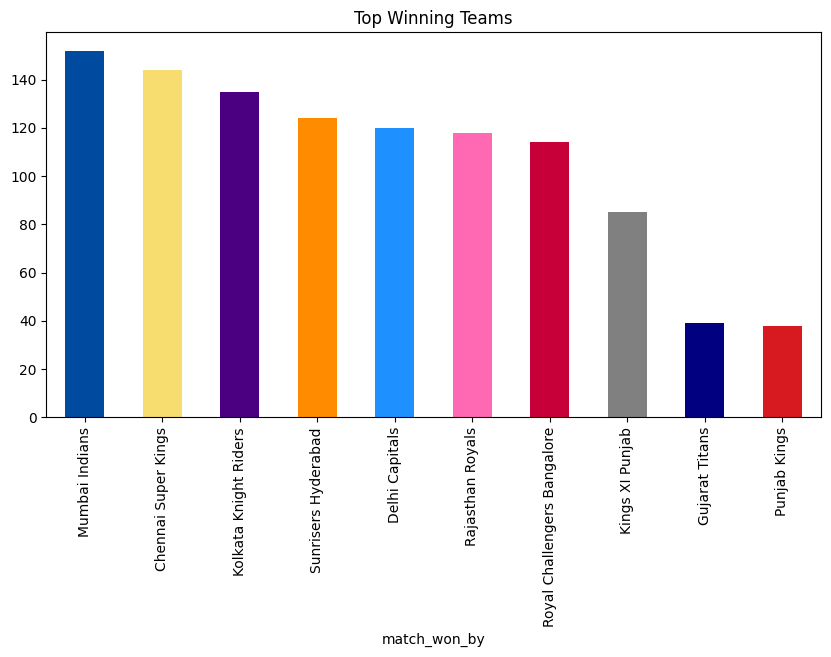

In [54]:
winners = df[['match_id','match_won_by']].drop_duplicates()
wins = winners['match_won_by'].value_counts()

colors = [team_colors.get(team, 'gray') for team in wins.index]

plt.figure(figsize=(10,5))
wins.head(10).plot(kind='bar', color=colors[:10])

plt.title("Top Winning Teams")
plt.show()

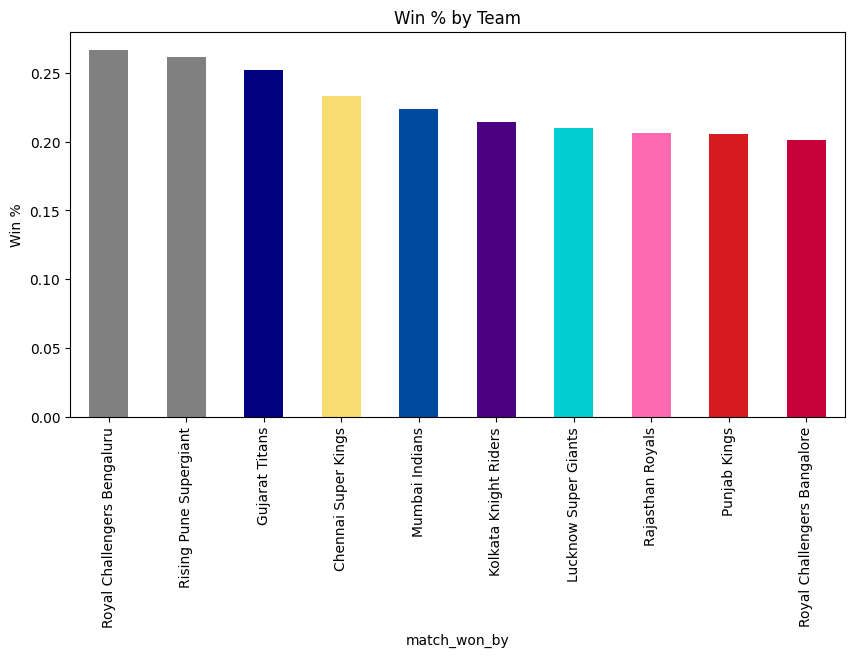

In [55]:
matches_played = teams.value_counts()
wins = winners['match_won_by'].value_counts()

win_pct = (wins / matches_played) * 100
win_pct = win_pct.sort_values(ascending=False)

colors = [team_colors.get(team, 'gray') for team in win_pct.index]

plt.figure(figsize=(10,5))
win_pct.head(10).plot(kind='bar', color=colors[:10])

plt.title("Win % by Team")
plt.ylabel("Win %")
plt.show()

In [56]:
toss_impact = (df['toss_winner'] == df['match_won_by']).mean() * 100
print("Toss Win → Match Win %:", toss_impact)

Toss Win → Match Win %: 50.53017858275932


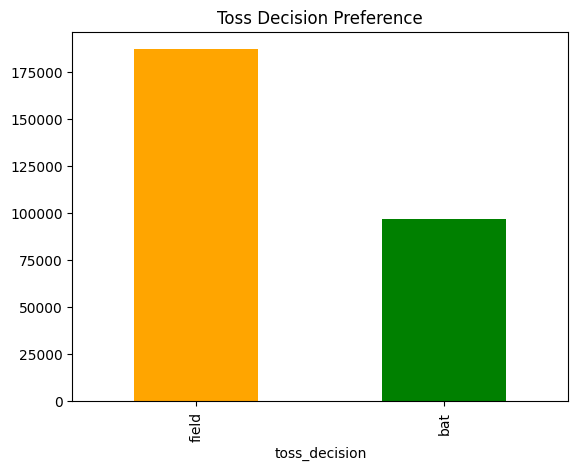

In [57]:
df['toss_decision'].value_counts().plot(
    kind='bar',
    color=['orange','green']
)

plt.title("Toss Decision Preference")
plt.show()

In [58]:
pd.crosstab(df['toss_decision'], df['match_won_by'])

match_won_by,Chennai Super Kings,Delhi Capitals,Gujarat Lions,Gujarat Titans,Kings XI Punjab,Kochi Tuskers Kerala,Kolkata Knight Riders,Lucknow Super Giants,Mumbai Indians,Pune Warriors,Punjab Kings,Rajasthan Royals,Rising Pune Supergiant,Rising Pune Supergiants,Royal Challengers Bangalore,Royal Challengers Bengaluru,Sunrisers Hyderabad,Unknown
toss_decision,,,,,,,,,,,,,,,,,,
bat,15616,10278,479,2105,5394,0,12086,1707,12869,2140,1625,10392,0,468,8706,254,10838,1844
field,19262,18193,2584,7386,14768,1322,19643,6218,23563,743,7517,17903,2383,637,18095,4940,18840,2880


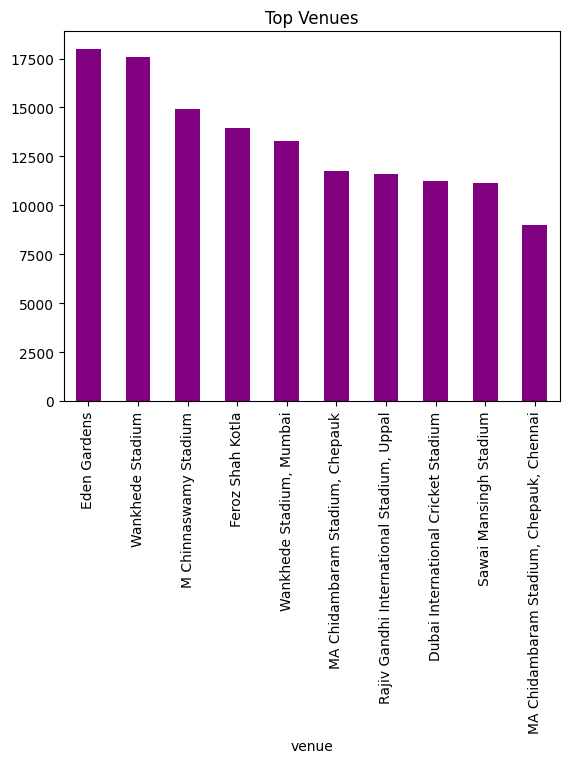

In [59]:
df['venue'].value_counts().head(10).plot(
    kind='bar',
    color='purple'
)

plt.title("Top Venues")
plt.show()

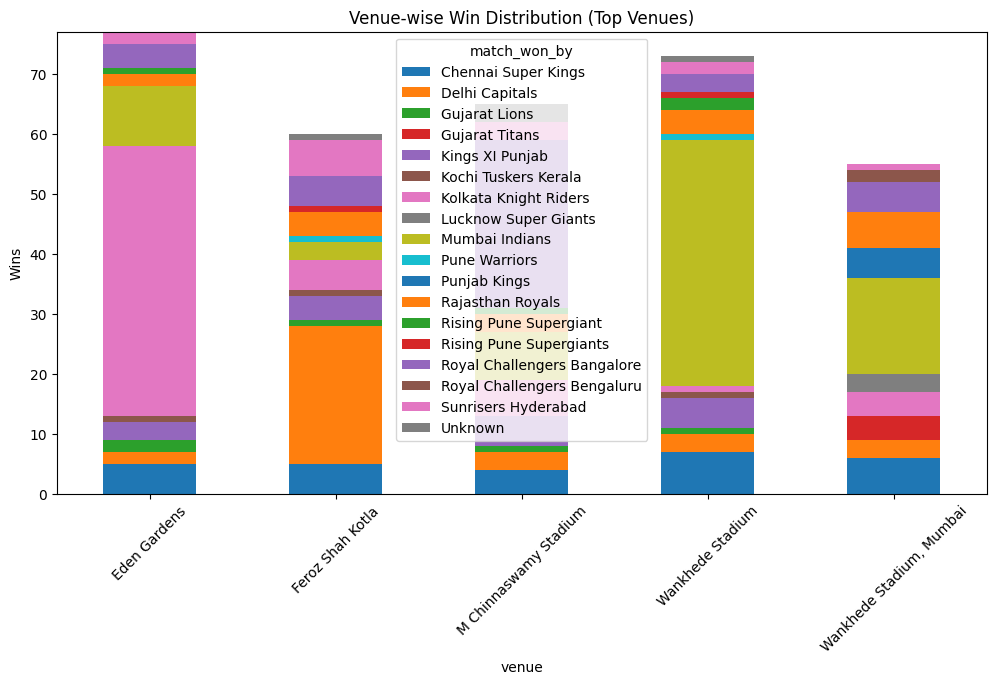

In [63]:
venue_wins = df[['match_id','venue','match_won_by']].drop_duplicates()

top_venues = venue_wins['venue'].value_counts().head(5).index

filtered = venue_wins[venue_wins['venue'].isin(top_venues)]

pivot = filtered.pivot_table(index='venue', columns='match_won_by', aggfunc='size', fill_value=0)

pivot.plot(kind='bar', stacked=True, figsize=(12,6))

plt.title("Venue-wise Win Distribution (Top Venues)")
plt.ylabel("Wins")
plt.xticks(rotation=45)
plt.show()

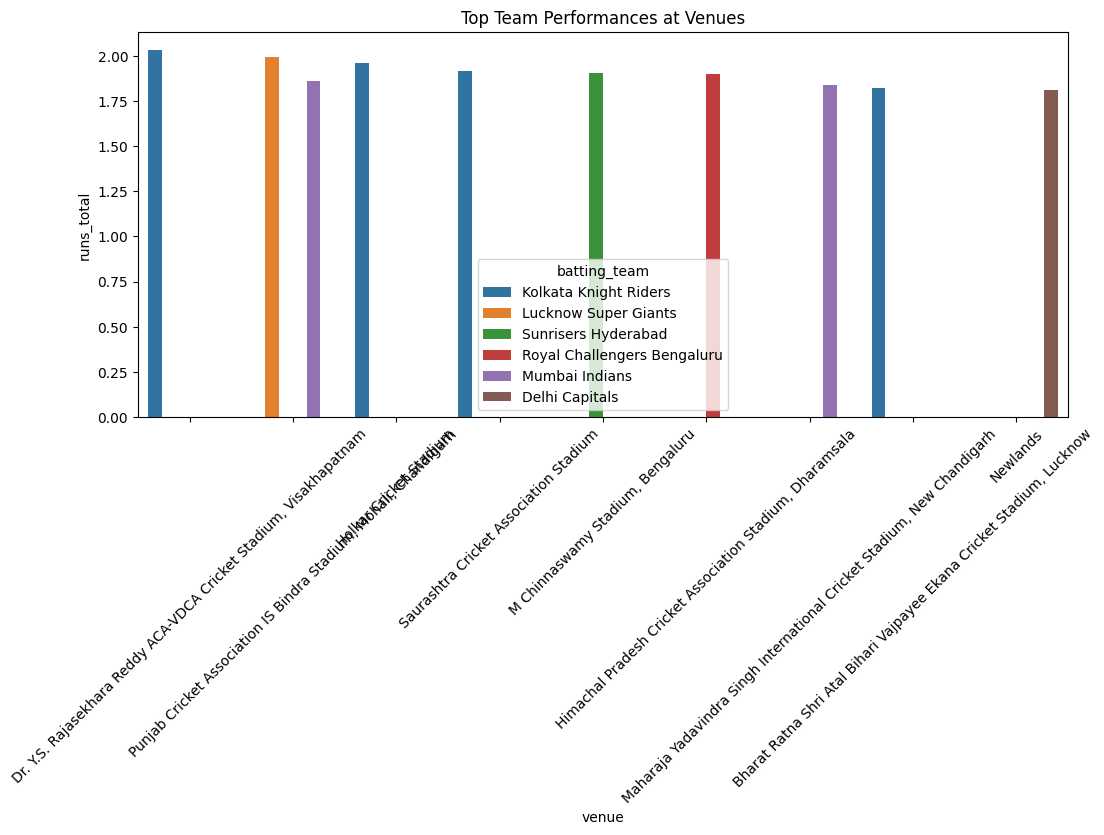

In [64]:
venue_team_perf = df.groupby(['venue','batting_team'])['runs_total'].mean().reset_index()

top = venue_team_perf.sort_values('runs_total', ascending=False).head(10)

plt.figure(figsize=(12,5))
sns.barplot(data=top, x='venue', y='runs_total', hue='batting_team')

plt.title("Top Team Performances at Venues")
plt.xticks(rotation=45)
plt.show()

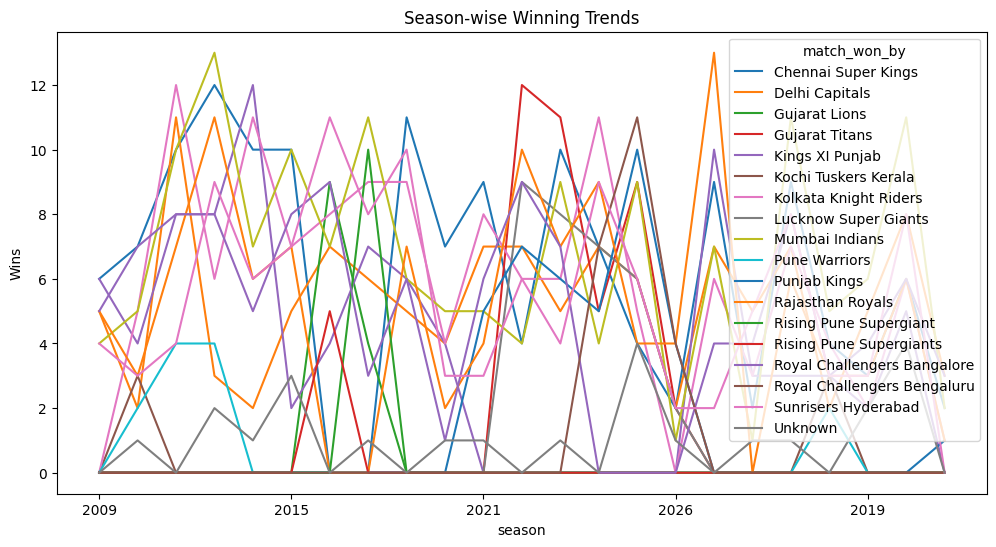

In [66]:
season_winners = df[['match_id','season','match_won_by']].drop_duplicates()

trend = season_winners.groupby(['season','match_won_by']).size().unstack(fill_value=0)

trend.plot(figsize=(12,6))

plt.title("Season-wise Winning Trends")
plt.ylabel("Wins")
plt.show()

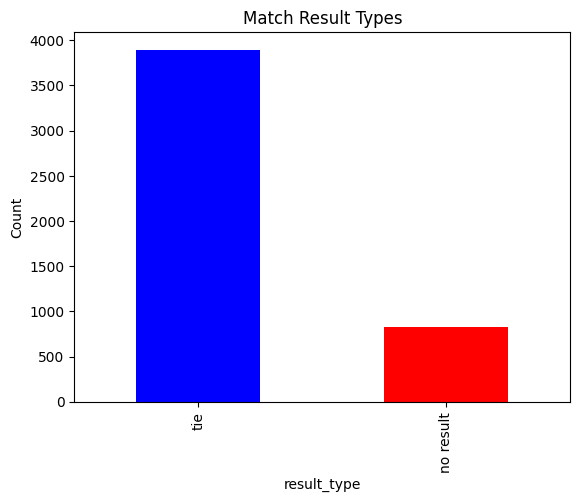

In [67]:
df['result_type'].value_counts().plot(kind='bar', color=['blue','red','gray'])

plt.title("Match Result Types")
plt.ylabel("Count")
plt.show()

In [68]:
close_matches = df[df['team_runs'] < 160]  # low scoring = tighter games

close_matches['match_id'].nunique()

1193

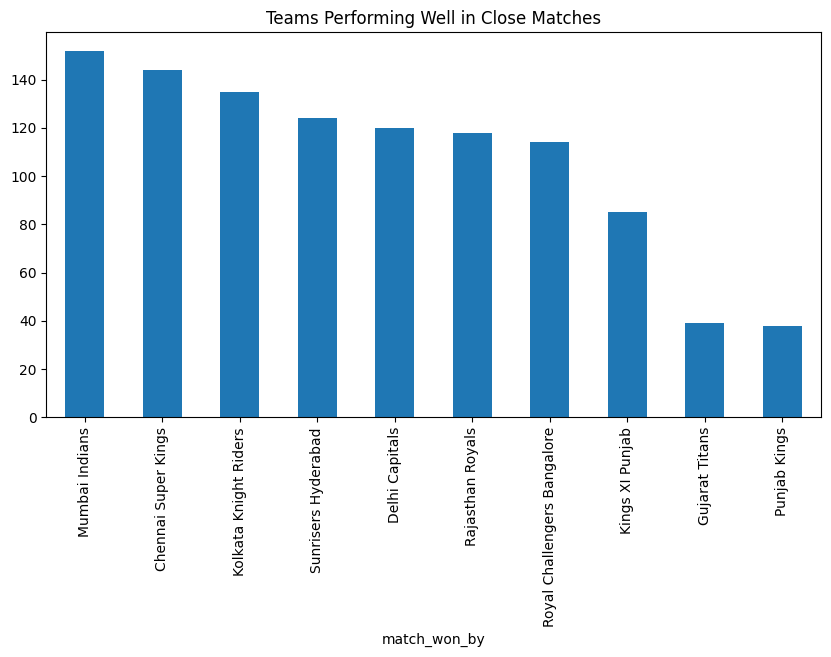

In [69]:
close_winners = close_matches[['match_id','match_won_by']].drop_duplicates()

top_close = close_winners['match_won_by'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_close.plot(kind='bar')

plt.title("Teams Performing Well in Close Matches")
plt.show()

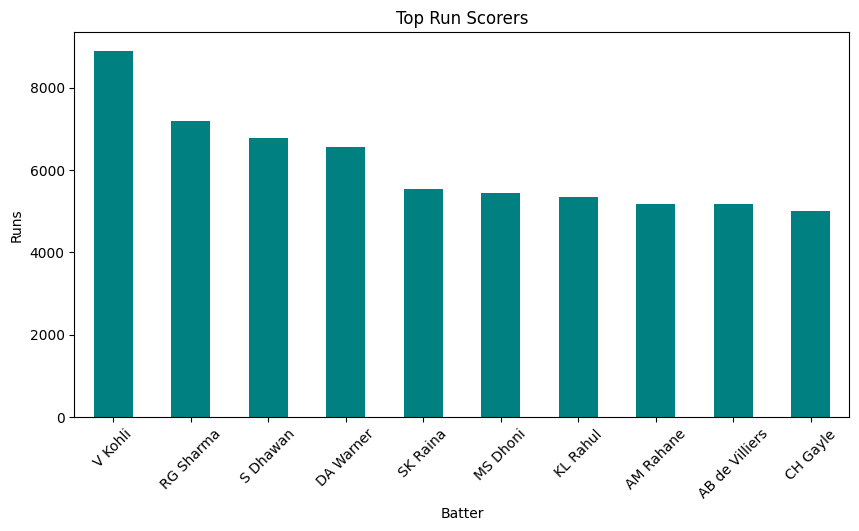

In [70]:
top_batsmen = df.groupby('batter')['runs_batter'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_batsmen.plot(kind='bar', color='teal')

plt.title("Top Run Scorers")
plt.xlabel("Batter")
plt.ylabel("Runs")
plt.xticks(rotation=45)
plt.show()

In [71]:
season_batsmen = df.groupby(['season','batter'])['runs_batter'].sum().reset_index()

top_season = season_batsmen.sort_values(['season','runs_batter'], ascending=[True, False])

top_season.groupby('season').head(1)

,season,batter,runs_batter
64,2009,ML Hayden,380
156,2011,CH Gayle,480
317,2012,CH Gayle,733
543,2013,MEK Hussey,733
721,2014,RV Uthappa,660
781,2015,DA Warner,562
1016,2016,V Kohli,973
1055,2017,DA Warner,641
1227,2018,KS Williamson,735
1322,2019,DA Warner,400


In [72]:
bat = df.groupby('batter').agg({
    'batter_runs':'sum',
    'batter_balls':'sum'
})

bat['strike_rate'] = (bat['batter_runs'] / bat['batter_balls']) * 100

top_sr = bat[bat['batter_balls'] > 300].sort_values('strike_rate', ascending=False).head(10)

top_sr

,batter_runs,batter_balls,strike_rate
batter,,,
V Suryavanshi,5953,2576,231.094720
Priyansh Arya,8780,4394,199.817934
R Shepherd,1299,672,193.303571
A Mhatre,6962,3717,187.301587
J Fraser-McGurk,4290,2302,186.359687
V Nigam,1185,636,186.320755
SP Narine,21352,11686,182.714359
K Gowtham,1291,718,179.805014
PD Salt,18020,10169,177.205232


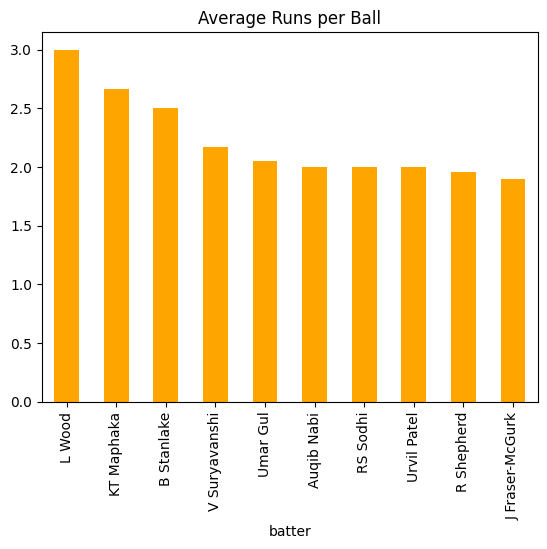

In [73]:
avg_runs = df.groupby('batter')['runs_batter'].mean().sort_values(ascending=False).head(10)

avg_runs.plot(kind='bar', color='orange')

plt.title("Average Runs per Ball")
plt.show()

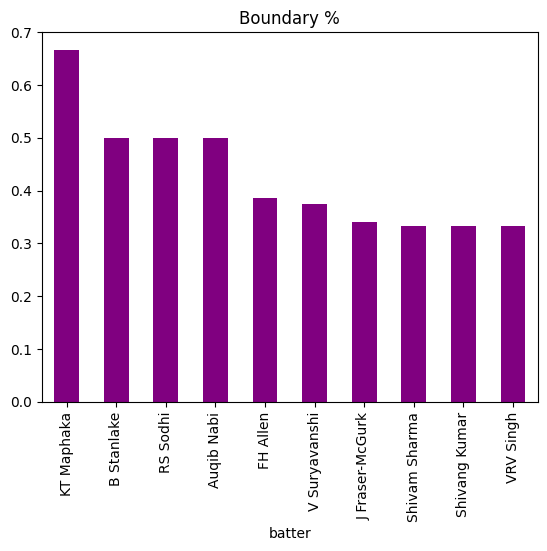

In [74]:
boundary_pct = df.groupby('batter')['is_boundary'].mean().sort_values(ascending=False).head(10)

boundary_pct.plot(kind='bar', color='purple')

plt.title("Boundary %")
plt.show()

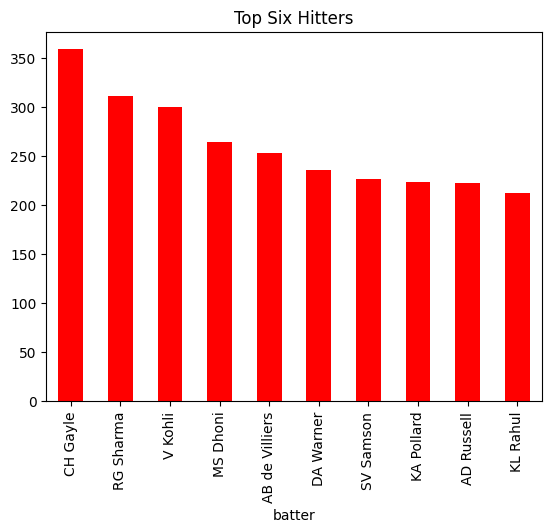

In [75]:
sixes = df[df['runs_batter']==6]['batter'].value_counts().head(10)

sixes.plot(kind='bar', color='red')

plt.title("Top Six Hitters")
plt.show()

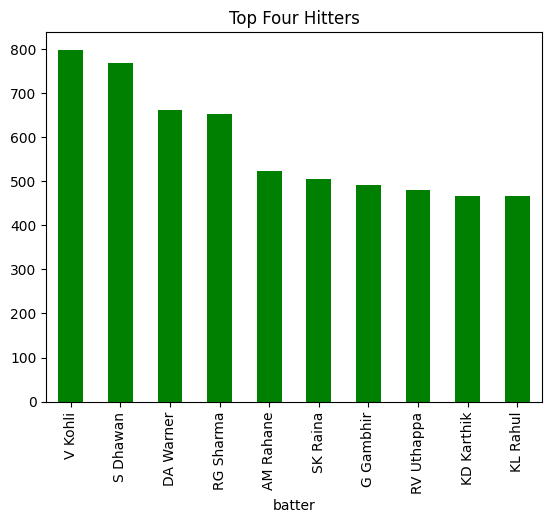

In [76]:
fours = df[df['runs_batter']==4]['batter'].value_counts().head(10)

fours.plot(kind='bar', color='green')

plt.title("Top Four Hitters")
plt.show()

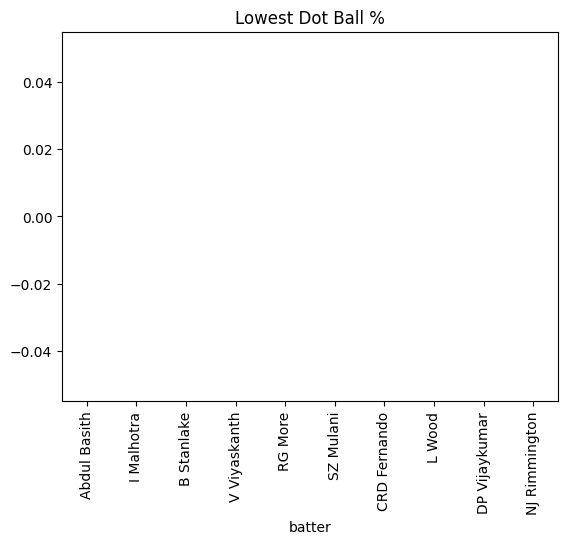

In [77]:
df['is_dot'] = (df['runs_batter']==0).astype(int)

dot = df.groupby('batter')['is_dot'].mean().sort_values().head(10)

dot.plot(kind='bar', color='black')

plt.title("Lowest Dot Ball %")
plt.show()

In [78]:
cons = df.groupby('batter')['runs_batter'].agg(['mean','std'])

cons['score'] = cons['mean'] / cons['std']

cons.sort_values('score', ascending=False).head(10)

,mean,std,score
batter,,,
RG More,1.000000,0.000000,inf
CRD Fernando,1.333333,0.577350,2.309401
V Viyaskanth,1.400000,0.894427,1.565248
S Tyagi,0.750000,0.500000,1.500000
DA Payne,1.200000,0.836660,1.434274
SJ Srivastava,1.000000,0.707107,1.414214
JP Behrendorff,0.666667,0.500000,1.333333
BMAJ Mendis,0.851852,0.662379,1.286048
DAJ Bracewell,1.333333,1.118034,1.192570


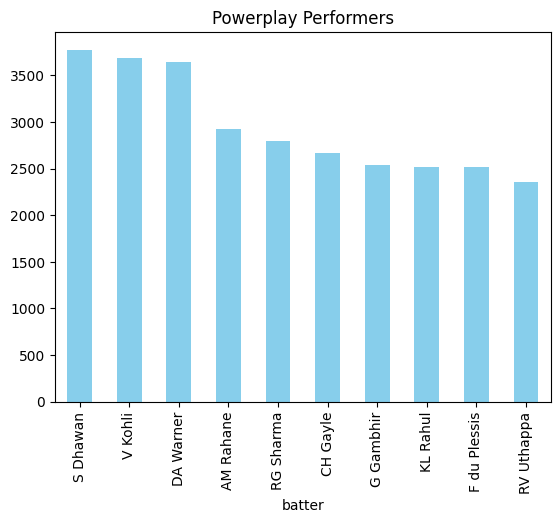

In [79]:
pp = df[df['over'] <= 6]

pp_runs = pp.groupby('batter')['runs_batter'].sum().sort_values(ascending=False).head(10)

pp_runs.plot(kind='bar', color='skyblue')

plt.title("Powerplay Performers")
plt.show()

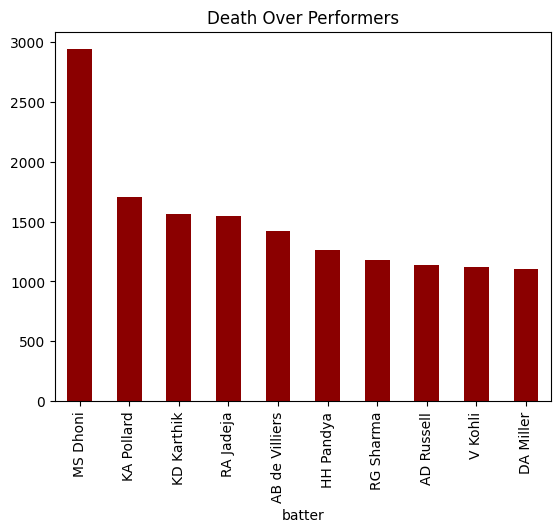

In [80]:
death = df[df['over'] >= 16]

death_runs = death.groupby('batter')['runs_batter'].sum().sort_values(ascending=False).head(10)

death_runs.plot(kind='bar', color='darkred')

plt.title("Death Over Performers")
plt.show()

In [81]:
top_order = df[df['bat_pos'] <= 3]

top_order.groupby('batter')['runs_batter'].sum().sort_values(ascending=False).head(10)

batter
V Kohli         8062
S Dhawan        6626
DA Warner       6029
CH Gayle        4993
AM Rahane       4952
SK Raina        4942
KL Rahul        4739
F du Plessis    4306
RG Sharma       4225
G Gambhir       4109
Name: runs_batter, dtype: int64

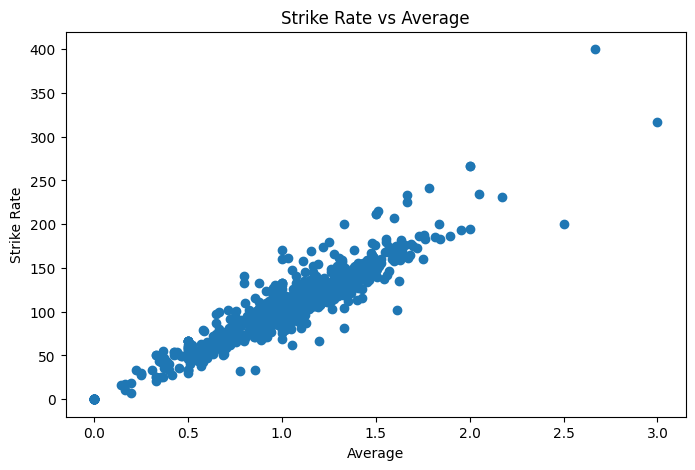

In [82]:
bat['avg'] = df.groupby('batter')['runs_batter'].mean()

plt.figure(figsize=(8,5))
plt.scatter(bat['avg'], bat['strike_rate'])

plt.xlabel("Average")
plt.ylabel("Strike Rate")
plt.title("Strike Rate vs Average")

plt.show()

In [83]:
bat[['avg','strike_rate']].sort_values('strike_rate', ascending=False).head(10)

,avg,strike_rate
batter,,
KT Maphaka,2.666667,400.000000
L Wood,3.000000,316.666667
Auqib Nabi,2.000000,266.666667
RS Sodhi,2.000000,266.666667
Akash Deep,1.785714,240.909091
Umar Gul,2.052632,234.146341
KMDN Kulasekara,1.666667,233.333333
V Suryavanshi,2.173077,231.094720
Shivam Sharma,1.666667,225.000000


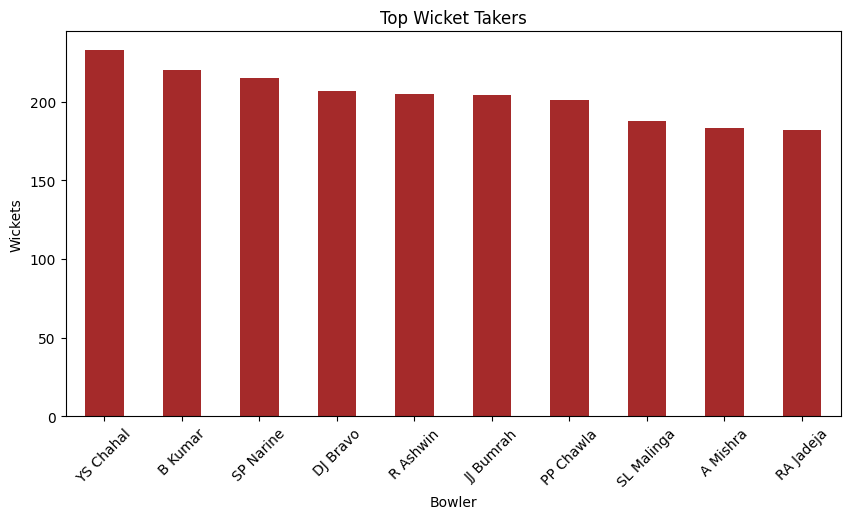

In [84]:
top_bowlers = df[df['is_wicket'] == 1]['bowler'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_bowlers.plot(kind='bar', color='brown')

plt.title("Top Wicket Takers")
plt.xlabel("Bowler")
plt.ylabel("Wickets")
plt.xticks(rotation=45)
plt.show()

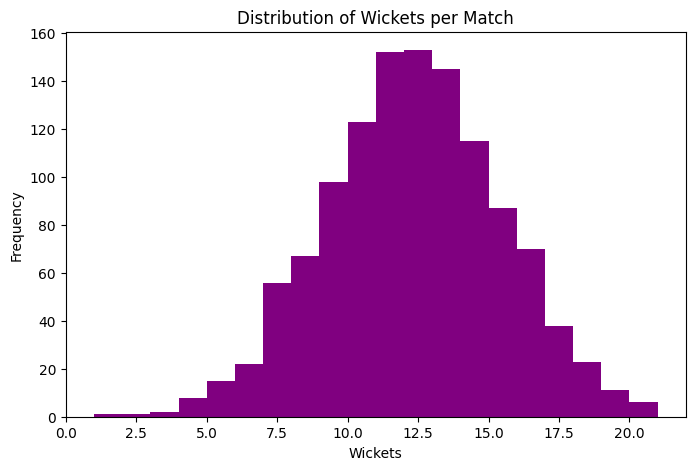

In [85]:
wickets_per_match = df.groupby('match_id')['is_wicket'].sum()

plt.figure(figsize=(8,5))
wickets_per_match.plot(kind='hist', bins=20, color='purple')

plt.title("Distribution of Wickets per Match")
plt.xlabel("Wickets")
plt.show()

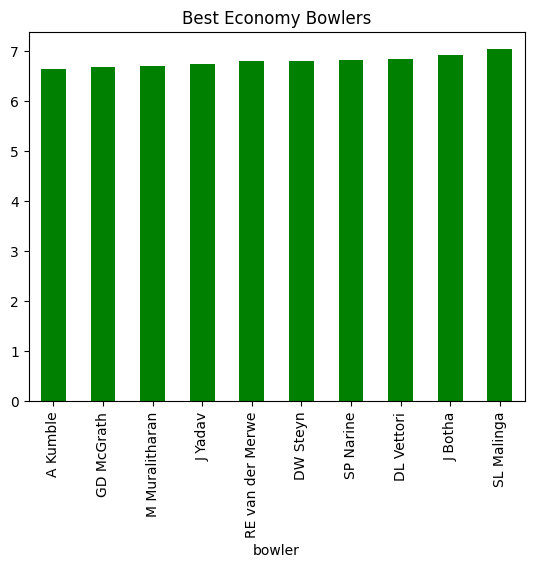

In [86]:
bowl = df.groupby('bowler').agg({
    'runs_total':'sum',
    'ball':'count'
})

bowl['overs'] = bowl['ball'] / 6
bowl['economy'] = bowl['runs_total'] / bowl['overs']

top_economy = bowl[bowl['overs'] > 50].sort_values('economy').head(10)

top_economy['economy'].plot(kind='bar', color='green')

plt.title("Best Economy Bowlers")
plt.show()

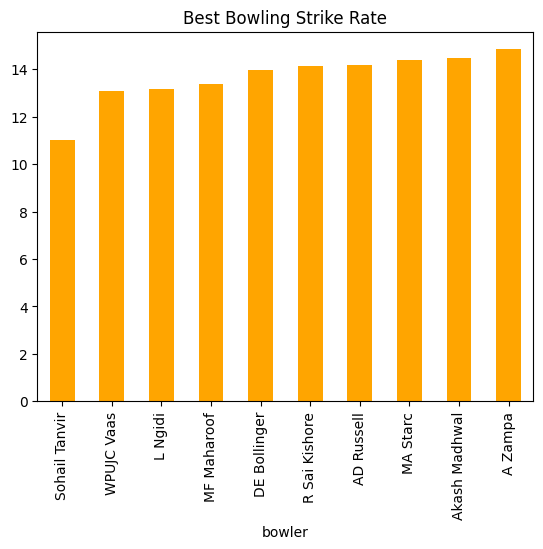

In [88]:
wickets = df.groupby('bowler')['is_wicket'].sum()

bowl['wickets'] = wickets
bowl['strike_rate'] = bowl['ball'] / bowl['wickets']

top_sr = bowl[bowl['wickets'] > 20].sort_values('strike_rate').head(10)

top_sr['strike_rate'].plot(kind='bar', color='orange')

plt.title("Best Bowling Strike Rate")
plt.show()

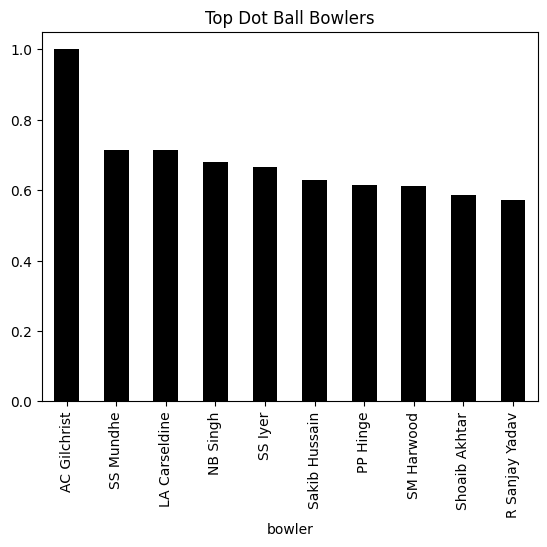

In [89]:
dot_bowlers = df.groupby('bowler')['is_dot'].mean().sort_values(ascending=False).head(10)

dot_bowlers.plot(kind='bar', color='black')

plt.title("Top Dot Ball Bowlers")
plt.show()

In [90]:
pp_wickets = df[df['over'] <= 6]['bowler'].value_counts().head(10)
death_wickets = df[df['over'] >= 16]['bowler'].value_counts().head(10)

pp_wickets
death_wickets

bowler
B Kumar           1374
JJ Bumrah         1269
DJ Bravo          1179
SL Malinga         965
SP Narine          779
HV Patel           757
MM Sharma          750
Sandeep Sharma     706
Mohammed Siraj     671
TA Boult           663
Name: count, dtype: int64

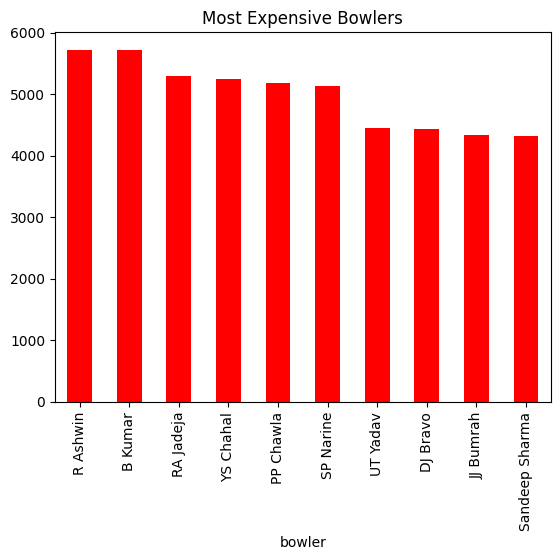

In [91]:
expensive = df.groupby('bowler')['runs_total'].sum().sort_values(ascending=False).head(10)

expensive.plot(kind='bar', color='red')

plt.title("Most Expensive Bowlers")
plt.show()

In [92]:
vs_team = df.groupby(['bowler','batting_team'])['is_wicket'].sum().reset_index()

vs_team.sort_values('is_wicket', ascending=False).head(10)

,bowler,batting_team,is_wicket
3032,SL Malinga,Chennai Super Kings,37
795,DJ Bravo,Mumbai Indians,36
1364,JJ Bumrah,Delhi Capitals,36
2035,MM Sharma,Mumbai Indians,35
54,A Mishra,Rajasthan Royals,34
3089,SP Narine,Delhi Capitals,34
3639,YS Chahal,Kolkata Knight Riders,33
485,B Kumar,Kolkata Knight Riders,33
3042,SL Malinga,Sunrisers Hyderabad,33
2507,R Ashwin,Delhi Capitals,32


In [93]:
win_bowl = df[df['bowling_team'] == df['match_won_by']]

win_bowl.groupby('bowler')['is_wicket'].sum().sort_values(ascending=False).head(10)

bowler
SL Malinga         135
YS Chahal          135
SP Narine          133
DJ Bravo           132
RA Jadeja          129
JJ Bumrah          126
R Ashwin           124
B Kumar            122
PP Chawla          116
Harbhajan Singh    113
Name: is_wicket, dtype: int64

In [94]:
bowl['consistency'] = bowl['economy'] / bowl['strike_rate']
bowl.sort_values('consistency').head(10)

,runs_total,ball,overs,economy,wickets,strike_rate,consistency
bowler,,,,,,,
YBK Jaiswal,6,1,0.166667,36.000000,0,inf,0.0
VS Yeligati,61,32,5.333333,11.437500,0,inf,0.0
Vivrant Sharma,37,21,3.500000,10.571429,0,inf,0.0
AS Raut,45,30,5.000000,9.000000,0,inf,0.0
Monu Kumar,20,16,2.666667,7.500000,0,inf,0.0
TH David,18,6,1.000000,18.000000,0,inf,0.0
NA Saini,35,15,2.500000,14.000000,0,inf,0.0
N Wadhera,22,17,2.833333,7.764706,0,inf,0.0
MG Neser,62,25,4.166667,14.880000,0,inf,0.0


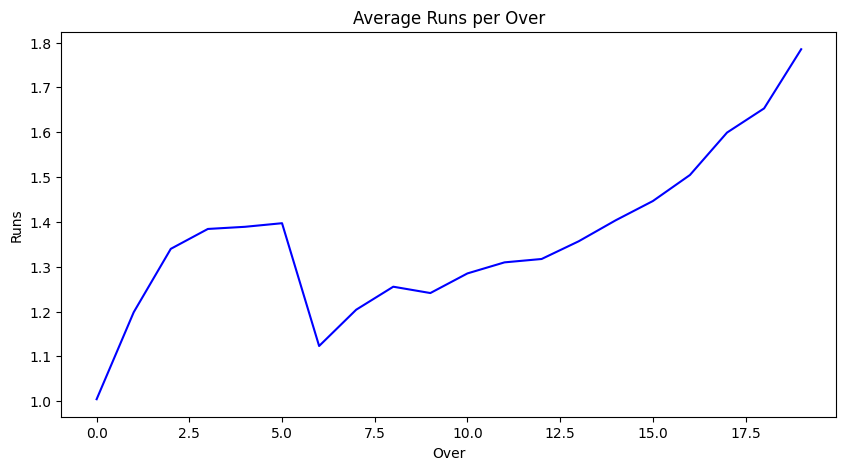

In [95]:
runs_per_over = df.groupby('over')['runs_total'].mean()

plt.figure(figsize=(10,5))
runs_per_over.plot(color='blue')

plt.title("Average Runs per Over")
plt.xlabel("Over")
plt.ylabel("Runs")
plt.show()

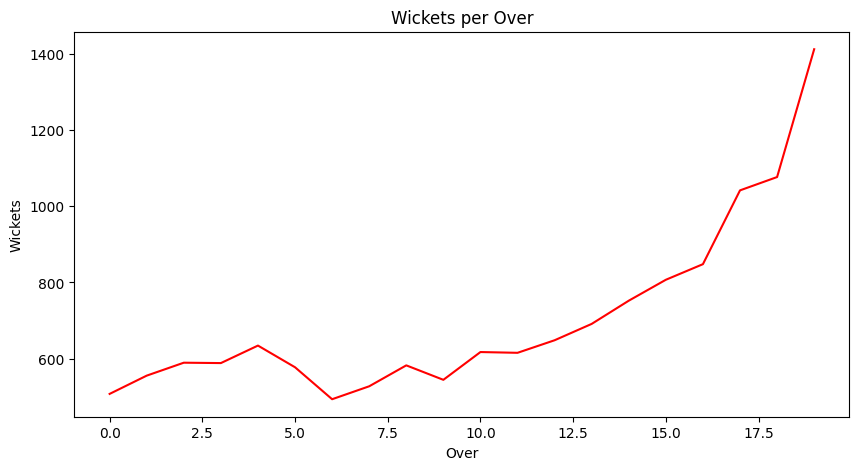

In [96]:
wickets_per_over = df.groupby('over')['is_wicket'].sum()

plt.figure(figsize=(10,5))
wickets_per_over.plot(color='red')

plt.title("Wickets per Over")
plt.xlabel("Over")
plt.ylabel("Wickets")
plt.show()

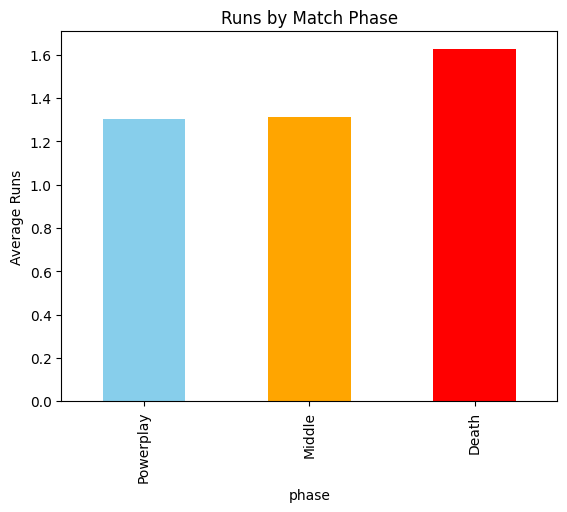

In [98]:
df['phase'] = pd.cut(df['over'], bins=[0,6,15,20], labels=['Powerplay','Middle','Death'])

phase_runs = df.groupby('phase')['runs_total'].mean()

phase_runs.plot(kind='bar', color=['skyblue','orange','red'])

plt.title("Runs by Match Phase")
plt.ylabel("Average Runs")
plt.show()

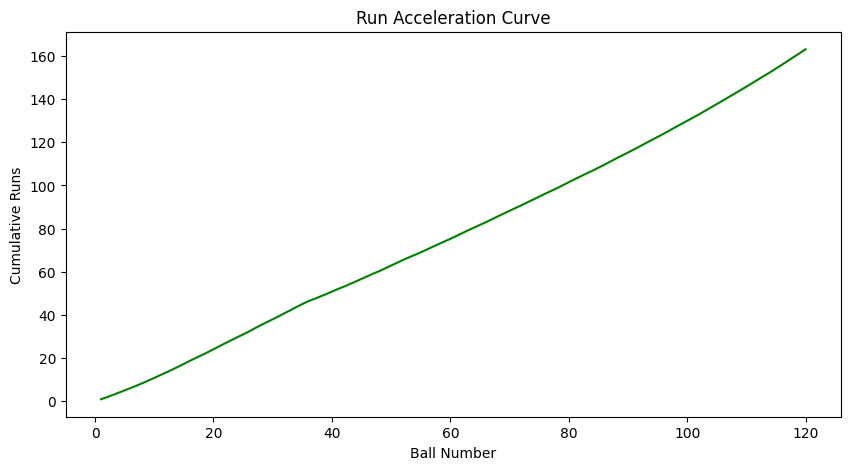

In [99]:
run_curve = df.groupby('total_balls')['runs_total'].mean().cumsum()

plt.figure(figsize=(10,5))
run_curve.plot(color='green')

plt.title("Run Acceleration Curve")
plt.xlabel("Ball Number")
plt.ylabel("Cumulative Runs")
plt.show()

In [100]:
# Approximation using innings
chasing = df[df['innings'] == 2]
defending = df[df['innings'] == 1]

chase_wins = chasing[chasing['batting_team'] == chasing['match_won_by']]['match_id'].nunique()
defend_wins = defending[defending['bowling_team'] == defending['match_won_by']]['match_id'].nunique()

print("Chasing Wins:", chase_wins)
print("Defending Wins:", defend_wins)

Chasing Wins: 635
Defending Wins: 635


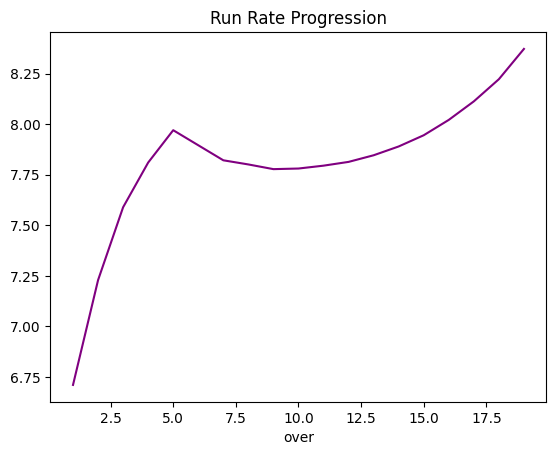

In [101]:
df['run_rate'] = df['team_runs'] / (df['team_balls']/6)

df.groupby('over')['run_rate'].mean().plot(color='purple')

plt.title("Run Rate Progression")
plt.show()

In [102]:
collapse = df.groupby(['match_id','over'])['is_wicket'].sum()

collapse[collapse >= 2].head(10)

match_id  over
335982    5       2
          8       2
335985    13      2
          18      2
335986    4       2
          8       2
          17      2
          18      2
335987    4       2
          17      2
Name: is_wicket, dtype: int64

In [103]:
partnership = df.groupby(['match_id','batting_partners'])['runs_total'].sum()

partnership.sort_values(ascending=False).head(10)

match_id  batting_partners                   
980987    ('AB de Villiers', 'V Kohli')          229
829795    ('AB de Villiers', 'V Kohli')          215
1426297   ('B Sai Sudharsan', 'Shubman Gill')    210
1304112   ('KL Rahul', 'Q de Kock')              210
501260    ('AC Gilchrist', 'SE Marsh')           206
1473498   ('B Sai Sudharsan', 'Shubman Gill')    205
548372    ('CH Gayle', 'V Kohli')                204
548329    ('DA Warner', 'NV Ojha')               189
1175366   ('DA Warner', 'JM Bairstow')           185
1082593   ('CA Lynn', 'G Gambhir')               184
Name: runs_total, dtype: int64

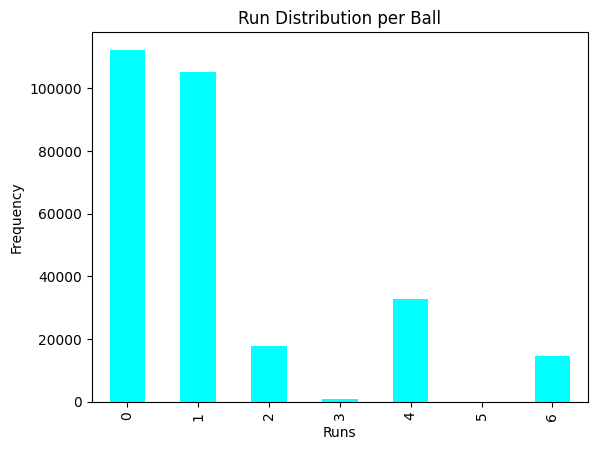

In [104]:
df['runs_batter'].value_counts().sort_index().plot(kind='bar', color='cyan')

plt.title("Run Distribution per Ball")
plt.xlabel("Runs")
plt.ylabel("Frequency")
plt.show()

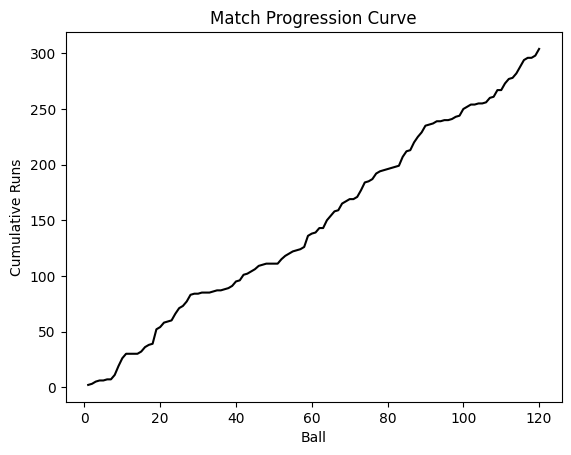

In [105]:
sample_match = df[df['match_id'] == df['match_id'].iloc[0]]

progress = sample_match.groupby('total_balls')['runs_total'].sum().cumsum()

progress.plot(color='black')

plt.title("Match Progression Curve")
plt.xlabel("Ball")
plt.ylabel("Cumulative Runs")
plt.show()

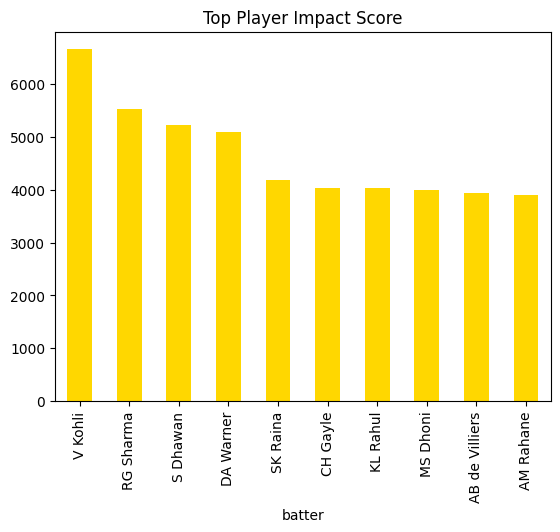

In [106]:
impact = df.groupby('batter').agg({
    'runs_batter':'sum',
    'is_boundary':'sum',
    'batter_balls':'sum'
})

impact['strike_rate'] = (impact['runs_batter'] / impact['batter_balls']) * 100

# Weighted score
impact['impact_score'] = (
    impact['runs_batter'] * 0.5 +
    impact['is_boundary'] * 2 +
    impact['strike_rate'] * 0.3
)

top_impact = impact.sort_values('impact_score', ascending=False).head(10)

top_impact['impact_score'].plot(kind='bar', color='gold')
plt.title("Top Player Impact Score")
plt.show()

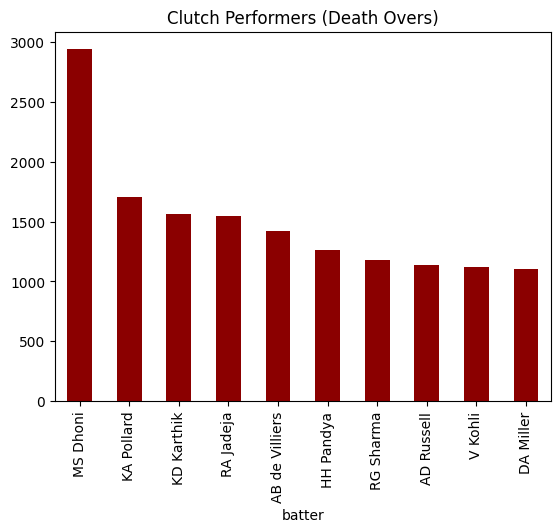

In [107]:
death = df[df['over'] >= 16]

clutch = death.groupby('batter')['runs_batter'].sum().sort_values(ascending=False).head(10)

clutch.plot(kind='bar', color='darkred')

plt.title("Clutch Performers (Death Overs)")
plt.show()

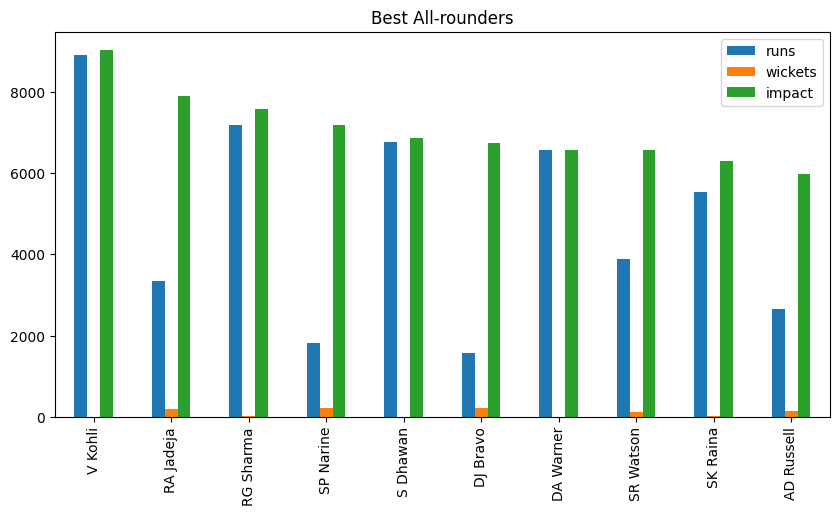

In [108]:
bat = df.groupby('batter')['runs_batter'].sum()
bowl = df.groupby('bowler')['is_wicket'].sum()

all_round = pd.concat([bat, bowl], axis=1).fillna(0)
all_round.columns = ['runs','wickets']

all_round['impact'] = all_round['runs'] + (all_round['wickets'] * 25)

top_allround = all_round.sort_values('impact', ascending=False).head(10)

top_allround.plot(kind='bar', figsize=(10,5))

plt.title("Best All-rounders")
plt.show()